In [100]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [101]:
K_COL = '/Volumes/easystore/proton-deuteron/col&ind/kaonscol.pkl'
K_IND = '/Volumes/easystore/proton-deuteron/col&ind/kaonsind.pkl'

k_col = pd.read_pickle(K_COL)
k_ind = pd.read_pickle(K_IND)

P_COL = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonscol.pkl'
P_IND = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonsind.pkl'

p_col = pd.read_pickle(P_COL)
p_ind = pd.read_pickle(P_IND)

masses = pd.read_csv('/Volumes/easystore/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. e.g. mass, if no. of particles = 1

col = pd.concat([k_col, p_col], ignore_index=True)
ind = pd.concat([k_ind, p_ind], ignore_index=True)

col = pd.merge(
    col,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

ind = pd.merge(
    ind,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

print(ind.shape, col.shape)

(10940, 38) (10940, 38)


In [102]:
trk = pd.read_csv('/Volumes/easystore/bruno/root/primary_trk_dedx_rr.csv')

In [103]:
trk

,run,subrun,event,itrk,iplane,npts,trkrr,trkdedx
0,8675,12,1249,0,1,62,0.2376;0.7127;1.1867;1.6596;2.1320;2.6051;3.07...,9.4013;8.9047;10.9794;8.6223;7.6075;8.3440;7.0...
1,8675,12,1250,0,1,62,27.7444;27.5310;27.1010;26.6720;26.2443;25.820...,1.5256;2.0464;1.5886;1.7815;1.8510;6.6998;4.18...
2,8675,12,1256,0,1,71,0.2387;0.7160;1.1994;1.6939;2.1632;2.6276;3.09...,33.8980;15.8514;13.0188;15.4676;13.1512;12.425...
3,8675,12,1257,0,1,174,83.7358;83.2654;82.7965;82.3260;81.8517;81.381...,1.8451;1.9248;1.6453;1.6211;2.2754;2.0665;1.94...
4,8675,12,1258,0,1,130,0.4724;1.4172;1.8982;2.3748;2.8527;3.3314;3.80...,236.6323;1.7058;2.0366;1.4391;1.6104;1.3819;1....
...,...,...,...,...,...,...,...,...
550244,9781,133,21589,0,1,22,0.2095;0.6286;1.0503;1.4751;1.8982;2.3233;2.74...,7.6253;6.9713;6.4090;7.2138;7.2675;8.3650;6.21...
550245,9781,133,21596,0,1,156,0.2277;0.6831;1.1396;1.5965;2.0518;2.5086;2.96...,16.8029;16.4499;14.7702;13.4497;12.5262;12.595...
550246,9781,133,21614,0,1,161,0.2387;0.7160;1.1939;1.6736;2.1529;2.6339;3.11...,2.5640;2.5399;3.9240;2.7486;4.1106;2.4086;3.22...
550247,9781,133,21621,0,1,173,0.2298;0.6893;1.1471;1.6058;2.0649;2.5229;2.98...,0.7744;0.7557;1.1643;0.8175;0.8054;1.0133;0.72...


In [104]:
def parse_array(cell):
    if pd.isna(cell) or cell == "":
        return np.array([], dtype=np.float32)
    return np.array([float(x) for x in cell.split(";")], dtype=np.float32)

trk["trkrr"]   = trk["trkrr"].apply(parse_array)
trk["trkdedx"] = trk["trkdedx"].apply(parse_array)

print(trk.shape, col.shape, ind.shape)

(550249, 8) (10940, 38) (10940, 38)


In [105]:
def filter_arrays(df):
    """Filter values > 70 from dedx arrays in the dataframe"""
    new_dedx = []
    new_rr = []
    
    for dedx, rr in zip(df['trkdedx'], df['trkrr']):
        indices = np.where(dedx > 100)[0]
        new_dedx.append(np.delete(dedx, indices))
        new_rr.append(np.delete(rr, indices))
    
    df['trkdedx'] = new_dedx
    df['trkrr'] = new_rr
    return df

trk = filter_arrays(trk)

print(trk.shape, col.shape, ind.shape)

(550249, 8) (10940, 38) (10940, 38)


In [106]:
trk = trk[trk["trkrr"].apply(len) > 0]
trk = trk[trk["trkrr"].apply(len) == trk["trkdedx"].apply(len)].reset_index(drop=True)

print(trk.shape, col.shape, ind.shape)

(550248, 8) (10940, 38) (10940, 38)


In [107]:
col = pd.merge(
    col,
    trk[['run', 'subrun', 'event', 'trkrr', 'trkdedx']],
    on=['run', 'subrun', 'event'],
    how='inner'
)

ind = pd.merge(
    ind,
    trk[['run', 'subrun', 'event', 'trkrr', 'trkdedx']],
    on=['run', 'subrun', 'event'],
    how='inner'
)

print(trk.shape, col.shape, ind.shape)

(550248, 8) (10905, 40) (10905, 40)


In [108]:
PROTONS_BB = '/Volumes/easystore/protons.txt'

bethe_data = np.loadtxt(PROTONS_BB)
resrange = bethe_data[:, 0]
bb_p = bethe_data[:, 1]
res_p = np.flip(resrange).copy()

KAONS_BB = '/Volumes/easystore/kaons.txt'

k_bethe = np.loadtxt(KAONS_BB)
dresrange = k_bethe[:, 0]
bb_k = k_bethe[:, 1]
res_k = np.flip(dresrange).copy()

In [109]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def build_res_index(res: np.ndarray) -> dict:
    """
    Map exact residual-range values (rounded to 2dp) -> index in res.
    This emulates: np.where(res == ro)[0][0] but fast.
    """
    res = np.asarray(res)
    # Alek compares floats directly; to make it robust while matching intent,
    # we store keys at 2dp (same as ro).
    keys = np.round(res.astype(np.float64), 2)
    # If duplicates exist, first occurrence matches np.where(...)[0][0]
    idx = {}
    for i, k in enumerate(keys):
        if k not in idx:
            idx[float(k)] = i
    return idx

def chi2_track_alek(rr, dedx, res_to_idx, bb, step=0.05):
    """
    Match Alek:
      ro = round(round(rr/0.05)*0.05, 2)
      x_l = np.where(res == ro)[0][0]
      chi += ((dedx - bb[x_l])**2) / bb[x_l]
      return chi / len(rr)
    Differences vs your earlier code:
      - no nearest neighbour
      - denominator is bb[x_l] (no eps clamp)
      - divides by len(x) (original length), not 'used' count
      - does not filter invalid points (unless you want to exactly match him)
    """
    rr = np.asarray(rr)
    dedx = np.asarray(dedx)
    if rr.size == 0 or rr.size != dedx.size:
        return np.nan

    chi = 0.0
    n = len(rr)

    for r, d in zip(rr, dedx):
        ro = round(round(float(r) / step) * step, 2)
        # exact match lookup like np.where(res == ro)[0][0]
        x_l = res_to_idx.get(ro, None)
        if x_l is None:
            # Alek would crash here. To stay compatible, return NaN (or raise).
            return np.nan
        exp = float(bb[x_l])
        chi += ((float(d) - exp) ** 2) / exp

    return chi / n

def do_chi_squared(df: pd.DataFrame,
                                  res_k: np.ndarray, bb_k: np.ndarray,
                                  res_p: np.ndarray, bb_p: np.ndarray,
                                  step: float = 0.05) -> pd.DataFrame:
    df = df.copy()

    # Build exact-match maps once
    resk_map = build_res_index(res_k)
    resp_map = build_res_index(res_p)

    pairs = list(zip(df["trkrr"], df["trkdedx"]))

    df["chi_squared_kaon"] = [
        chi2_track_alek(rr, dx, resk_map, bb_k, step=step)
        for rr, dx in tqdm(pairs, total=len(pairs), desc="chi^2 kaon (Alek-match)")
    ]

    df["chi_squared_proton"] = [
        chi2_track_alek(rr, dx, resp_map, bb_p, step=step)
        for rr, dx in tqdm(pairs, total=len(pairs), desc="chi^2 proton (Alek-match)")
    ]

    # Alek: kaon if chi_k < chi_p else proton
    df["particle_hypothesis"] = np.where(
        df["chi_squared_kaon"] < df["chi_squared_proton"], 0, 1
    )

    return df

In [110]:
col = do_chi_squared(col, res_k, bb_k, res_p, bb_p)
ind = do_chi_squared(ind, res_k, bb_k, res_p, bb_p)
print(col.shape)

chi^2 kaon (Alek-match):   0%|          | 0/10905 [00:00<?, ?it/s]

chi^2 proton (Alek-match):   0%|          | 0/10905 [00:00<?, ?it/s]

chi^2 kaon (Alek-match):   0%|          | 0/10905 [00:00<?, ?it/s]

chi^2 proton (Alek-match):   0%|          | 0/10905 [00:00<?, ?it/s]

(10905, 43)


In [111]:
col.columns

Index(['run', 'subrun', 'event', 'cluster_idx_ind', 'cluster_idx_col',
       'd_min_c', 'd_max_c', 'd_min_r', 'd_max_r', 'd_h', 'match_score',
       'event_idx', 'file_path', 'event_index', 'particle_type', 'plane',
       'cluster_idx', 'area', 'max_intensity', 'min_intensity',
       'mean_intensity', 'total_intensity', 'centroid_x', 'centroid_y',
       'bbox_min_row', 'bbox_min_col', 'bbox_max_row', 'bbox_max_col', 'width',
       'height', 'aspect_ratio', 'compactness', 'image_intensity',
       'matrix_transformed', 'column_maxes', 'p', 'm', 'beamline_mass',
       'trkrr', 'trkdedx', 'chi_squared_kaon', 'chi_squared_proton',
       'particle_hypothesis'],
      dtype='object')

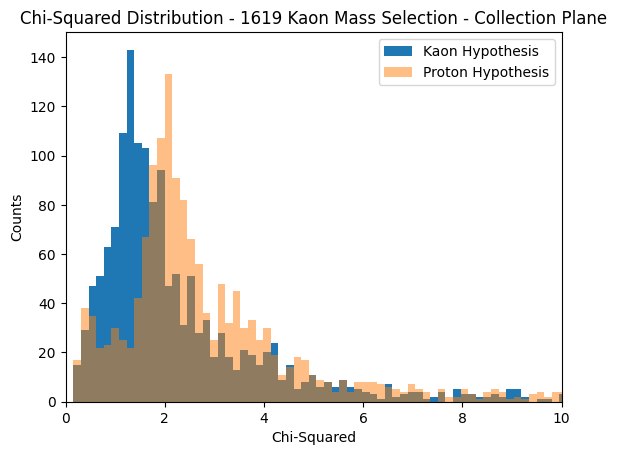

In [115]:
bins = np.linspace(min(col[(col['particle_type']=='kaon')]['chi_squared_kaon'].values), max(col[col['particle_type']=='kaon']['chi_squared_kaon'].values), 2000)

n = len(col[col['particle_type']=='kaon'])

plt.hist(col[col['particle_type']=='kaon']['chi_squared_kaon'], bins=bins, label='Kaon Hypothesis')
plt.hist(col[col['particle_type']=='kaon']['chi_squared_proton'], bins=bins, alpha=0.5, label='Proton Hypothesis')
plt.title(f'Chi-Squared Distribution - {n} Kaon Mass Selection - Collection Plane')
plt.xlabel('Chi-Squared')
plt.ylabel('Counts')

plt.xlim(0, 10)
plt.legend()
plt.show()

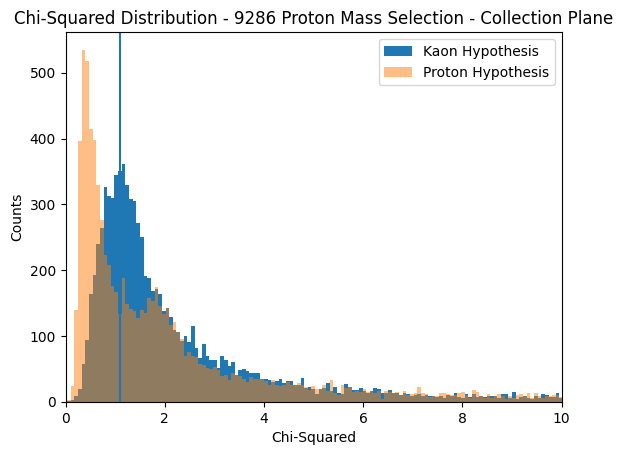

In [123]:
bins = np.linspace(min(col[col['particle_type']=='proton']['chi_squared_kaon'].values), max(col[col['particle_type']=='proton']['chi_squared_kaon'].values), 3000)

n = len(col[col['particle_type']=='proton'])

plt.hist(col[col['particle_type']=='proton']['chi_squared_kaon'], bins=bins, label='Kaon Hypothesis')
plt.hist(col[col['particle_type']=='proton']['chi_squared_proton'], bins=bins, alpha=0.5, label='Proton Hypothesis')
plt.title(f'Chi-Squared Distribution - {n} Proton Mass Selection - Collection Plane')
plt.xlabel('Chi-Squared')
plt.ylabel('Counts')

plt.axvline(1.1)

plt.xlim(0, 10)
plt.legend()
plt.show()

Different pattern due to:
- I'm not using golden protons like Alek, picky protons, this includes very short tracks and some muons. These will naturally introduce noise, giving an extra peak at around $\chi^2$ = 2.

In [114]:
# col.to_pickle('/Volumes/easystore/proton-deuteron/col&ind/chi-col.pkl')
# ind.to_pickle('/Volumes/easystore/proton-deuteron/col&ind/chi-ind.pkl')

In [126]:
anomaly = col[(col['particle_type']=='proton') & (col['chi_squared_proton'] > 1.1) & (col['chi_squared_proton'] < 4)]

(array([576., 547., 639., 504., 692., 626., 435., 579., 521., 290., 419.,
        394., 326., 219., 266., 229., 157., 215., 164., 129., 141., 128.,
        120.,  74.,  88.,  78.,  53.,  60.,  56.,  33.,  45.,  41.,  21.,
         30.,  40.,  32.,  14.,  21.,  18.,   9.,  16.,   9.,  18.,   5.,
          7.,   5.,   4.,   6.,   2.,   1.,  11., 140.,  33.]),
 array([  2.        ,   5.69811321,   9.39622642,  13.09433962,
         16.79245283,  20.49056604,  24.18867925,  27.88679245,
         31.58490566,  35.28301887,  38.98113208,  42.67924528,
         46.37735849,  50.0754717 ,  53.77358491,  57.47169811,
         61.16981132,  64.86792453,  68.56603774,  72.26415094,
         75.96226415,  79.66037736,  83.35849057,  87.05660377,
         90.75471698,  94.45283019,  98.1509434 , 101.8490566 ,
        105.54716981, 109.24528302, 112.94339623, 116.64150943,
        120.33962264, 124.03773585, 127.73584906, 131.43396226,
        135.13207547, 138.83018868, 142.52830189, 146.22641509,


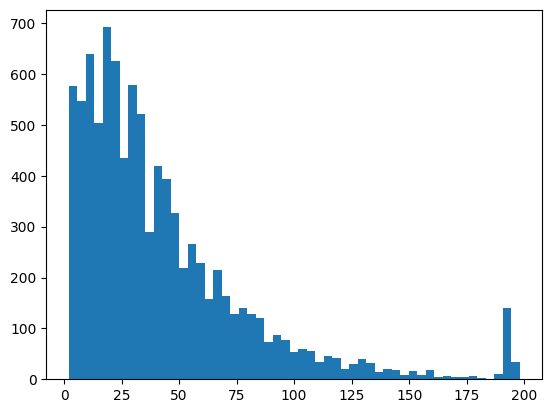

In [133]:
plt.hist(col[(col['particle_type']=='proton')]['height'], bins='auto')

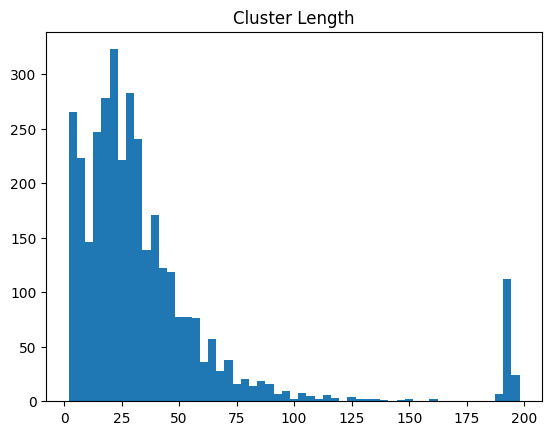

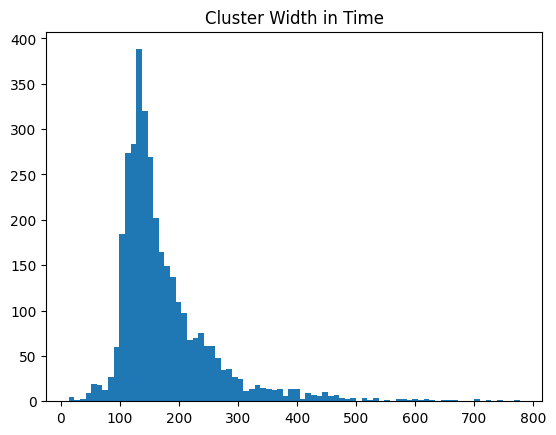

In [131]:
plt.hist(anomaly['height'], bins='auto')
plt.title('Cluster Length')
plt.show()

plt.hist(anomaly['width'], bins='auto')
plt.title('Cluster Width in Time')
plt.show()